# 04: 研报基准策略风险分析

对研报基准策略（Call 期权 + 固定波动率锥阈值 + Delta 对冲）进行系统性风险分析：

1. **Vega 风险拆解** — 隐含波动率变化对组合的影响
2. **Delta 风险拆解** — 离散对冲误差与方向性暴露
3. **Gamma 风险拆解** — 非线性价格风险，尤其临近到期
4. **组合 P&L 归因** — 将总收益分解为 Theta/Gamma/Vega/Delta/成本
5. **收益分布与回撤结构** — 偏度、峰度、VaR、ES、回撤分析

> 理论框架参见 `第四部分.tex`。

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline

sns.set_style('whitegrid')
from src.utils.visualize import setup_chinese_font
setup_chinese_font()

from src.data.preprocess import prepare_etf_daily, prepare_options_daily_with_greeks
from src.models.vol_cone import build_vol_cone, get_vol_threshold
from src.models.greeks import gamma as bsm_gamma, vega as bsm_vega, theta as bsm_theta
from src.strategy.backtest import VolArbBacktest

SAVE_DIR = '../Data/processed/'
print('Imports OK')

Matplotlib is building the font cache; this may take a moment.


Imports OK


## 0. 数据准备与基准回测

In [2]:
# 加载数据
etf = prepare_etf_daily(start_date='2010-01-01', end_date='2025-12-31')
opts_c = prepare_options_daily_with_greeks(start_date='2015-02-09', end_date='2025-12-31', option_type='C')
print(f'ETF: {etf.shape[0]} 天, {etf.index.min().date()} ~ {etf.index.max().date()}')
print(f'Call: {opts_c["code"].nunique()} 合约, {len(opts_c):,} 行')

# 固定阈值 (2010-2015 历史)
etf_pre = etf.loc[:'2015-02-08']
cone = build_vol_cone(etf_pre)
threshold = get_vol_threshold(cone, window=20, percentile=85)
print(f'固定阈值: {threshold*100:.2f}%')

ETF: 3885 天, 2010-01-04 ~ 2025-12-31
Call: 3400 合约, 229,074 行
固定阈值: 27.87%


In [3]:
# 运行基准回测并收集每日 Greeks
all_trades = []
all_daily_greeks = []
all_daily_pnl = []

expiries = sorted(opts_c['EXPIRY_DATE'].unique())
for i, expiry in enumerate(expiries):
    bt = VolArbBacktest(vol_threshold=threshold, r=0.04, commission_rate=0.0005,
                        min_t_days=2, option_type='call')
    result = bt.run(opts_c, etf, expiry_date=expiry, early_close=False)
    all_trades.extend(result.trades)
    if not result.daily_greeks.empty:
        all_daily_greeks.append(result.daily_greeks)
    if not result.equity_curve.empty:
        eq = result.equity_curve
        daily_delta = eq.diff().fillna(eq)
        all_daily_pnl.append(daily_delta)
    if (i+1) % 30 == 0:
        print(f'  Progress: {i+1}/{len(expiries)}')

# 汇总每日 Greeks
if all_daily_greeks:
    greeks_daily = pd.concat(all_daily_greeks)
    greeks_daily = greeks_daily.groupby(greeks_daily.index).agg({
        'etf_price': 'last',
        'num_positions': 'sum',
        'portfolio_delta': 'sum',
        'portfolio_delta_option': 'sum',
        'portfolio_gamma': 'sum',
        'portfolio_vega': 'sum',
        'portfolio_theta': 'sum',
    })
else:
    greeks_daily = pd.DataFrame()

# 汇总每日 P&L
if all_daily_pnl:
    combined = pd.concat(all_daily_pnl)
    equity = combined.groupby(combined.index).sum().cumsum()
else:
    equity = pd.Series(dtype=float)

print(f'\n基准回测完成: {len(all_trades)} 笔交易, {len(greeks_daily)} 天 Greeks 数据')
print(f'总 PnL: {sum(t.pnl for t in all_trades):,.0f} 元')

  Progress: 30/134
  Progress: 60/134
  Progress: 90/134
  Progress: 120/134

基准回测完成: 24042 笔交易, 2243 天 Greeks 数据
总 PnL: 1,737,284 元


In [4]:
# 计算每日市场 IV 变化 (使用期权数据的平均 IV)
daily_iv = opts_c.groupby('date')['iv'].mean()
greeks_daily['market_iv'] = daily_iv.reindex(greeks_daily.index)
greeks_daily['dS'] = greeks_daily['etf_price'].diff()
greeks_daily['dIV'] = greeks_daily['market_iv'].diff()
greeks_daily['daily_pnl'] = equity.diff().fillna(0).reindex(greeks_daily.index, fill_value=0)

# Greeks-based P&L attribution
greeks_daily['vega_pnl'] = greeks_daily['portfolio_vega'] * greeks_daily['dIV'] * 100  # vega is per 1%
greeks_daily['gamma_pnl'] = 0.5 * greeks_daily['portfolio_gamma'] * greeks_daily['dS']**2
greeks_daily['theta_pnl'] = greeks_daily['portfolio_theta']  # already per day
# Raw option delta contribution: cumulative tends to ~0 because E[dS] ≈ 0
# (the point of delta hedging is to cancel first-order price moves)
greeks_daily['delta_pnl'] = greeks_daily['portfolio_delta_option'] * greeks_daily['dS']
greeks_daily['residual_pnl'] = greeks_daily['daily_pnl'] - (
    greeks_daily['vega_pnl'] + greeks_daily['gamma_pnl'] +
    greeks_daily['theta_pnl'] + greeks_daily['delta_pnl']
)

print('Greeks 归因计算完成')
print(f'归因误差 (residual): mean={greeks_daily["residual_pnl"].mean():.1f}, std={greeks_daily["residual_pnl"].std():.1f}')

# Diagnostic: Delta P&L daily values are non-zero, but cumulative → 0
print(f'\nDelta P&L 诊断:')
print(f'  日均 |delta_pnl|: {greeks_daily["delta_pnl"].abs().mean():,.0f} 元')
print(f'  累计 delta_pnl: {greeks_daily["delta_pnl"].sum():,.0f} 元')
print(f'  日 dS 均值: {greeks_daily["dS"].mean():.5f}')
print(f'  说明: 日度 Delta P&L 波动显著，但 dS 均值≈0，累计趋零（一阶效应被对冲抵消）')

Greeks 归因计算完成
归因误差 (residual): mean=1108.6, std=277278.7

Delta P&L 诊断:
  日均 |delta_pnl|: 60,684 元
  累计 delta_pnl: 826,700 元
  日 dS 均值: 0.00034
  说明: 日度 Delta P&L 波动显著，但 dS 均值≈0，累计趋零（一阶效应被对冲抵消）


## 1. Vega 风险拆解

Vega 衡量期权价格对隐含波动率变化的敏感性。本策略卖出期权，Vega 为负，隐含波动率上升会导致亏损。

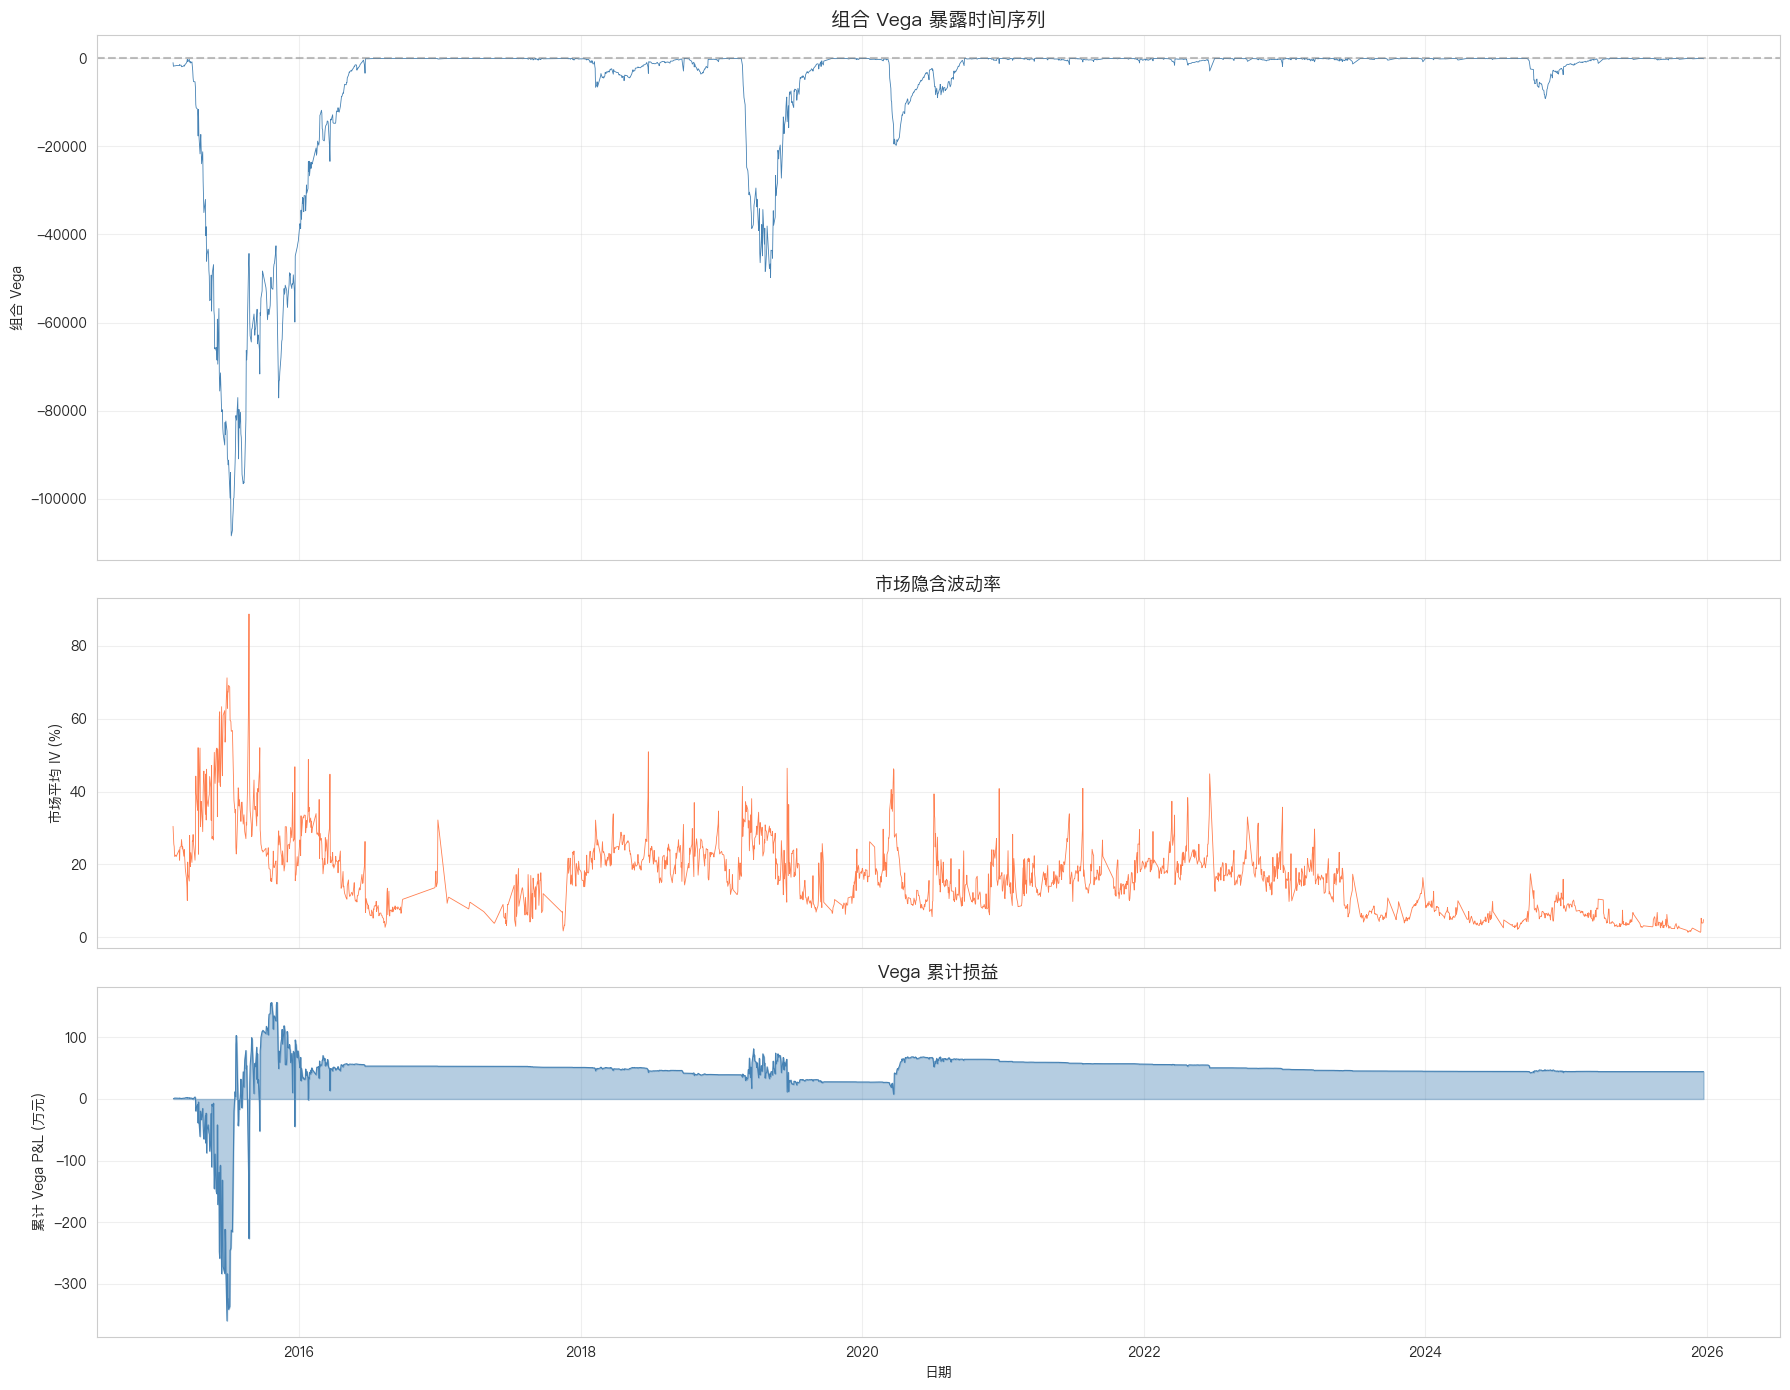

Vega 统计:
  平均 Vega: -7,739
  Vega 范围: [-108,471, 0]
  累计 Vega P&L: 443,901 元


In [5]:
# 1.1 组合 Vega 时间序列
fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True,
                         gridspec_kw={'height_ratios': [1.5, 1, 1]})

# Vega
axes[0].plot(greeks_daily.index, greeks_daily['portfolio_vega'], linewidth=0.6, color='steelblue')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_ylabel('组合 Vega')
axes[0].set_title('组合 Vega 暴露时间序列', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Market IV
axes[1].plot(greeks_daily.index, greeks_daily['market_iv'] * 100, linewidth=0.6, color='coral')
axes[1].set_ylabel('市场平均 IV (%)')
axes[1].set_title('市场隐含波动率', fontsize=13)
axes[1].grid(True, alpha=0.3)

# Vega P&L
axes[2].fill_between(greeks_daily.index, greeks_daily['vega_pnl'].cumsum() / 10000,
                     0, alpha=0.4, color='steelblue')
axes[2].plot(greeks_daily.index, greeks_daily['vega_pnl'].cumsum() / 10000,
             linewidth=0.8, color='steelblue')
axes[2].set_ylabel('累计 Vega P&L (万元)')
axes[2].set_xlabel('日期')
axes[2].set_title('Vega 累计损益', fontsize=13)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + '04_vega_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Vega 统计:')
print(f'  平均 Vega: {greeks_daily["portfolio_vega"].mean():,.0f}')
print(f'  Vega 范围: [{greeks_daily["portfolio_vega"].min():,.0f}, {greeks_daily["portfolio_vega"].max():,.0f}]')
print(f'  累计 Vega P&L: {greeks_daily["vega_pnl"].sum():,.0f} 元')

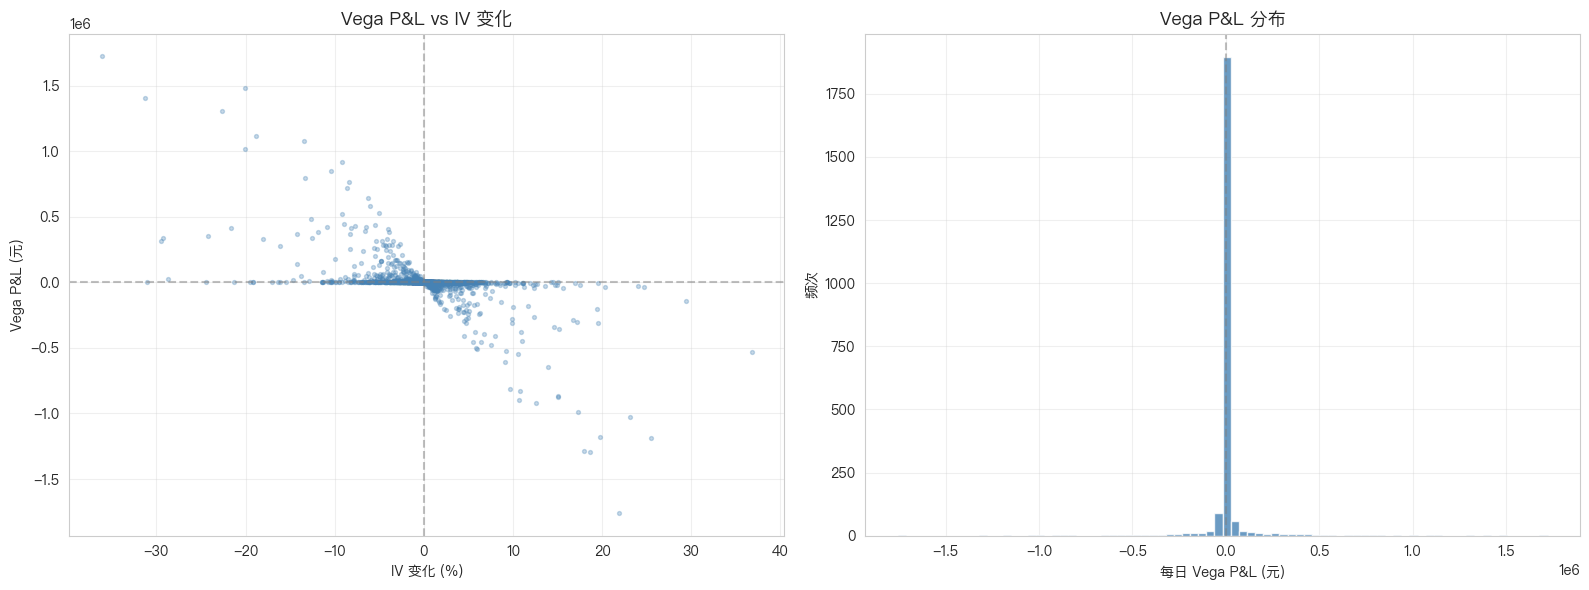

In [6]:
# 1.2 Vega 与 IV 变化散点图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Vega vs dIV
mask = greeks_daily['dIV'].notna() & greeks_daily['portfolio_vega'].notna()
axes[0].scatter(greeks_daily.loc[mask, 'dIV'] * 100,
                greeks_daily.loc[mask, 'vega_pnl'],
                alpha=0.3, s=8, color='steelblue')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('IV 变化 (%)')
axes[0].set_ylabel('Vega P&L (元)')
axes[0].set_title('Vega P&L vs IV 变化', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Vega P&L distribution
axes[1].hist(greeks_daily['vega_pnl'].dropna(), bins=80, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('每日 Vega P&L (元)')
axes[1].set_ylabel('频次')
axes[1].set_title('Vega P&L 分布', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + '04_vega_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

=== Vega 压力测试 ===
     IV 冲击     单日 Vega PnL     占总 PnL 比
----------------------------------------
       +3%         -23,216        -1.3%
       +5%         -38,693        -2.2%
      +10%         -77,385        -4.5%
      +15%        -116,078        -6.7%


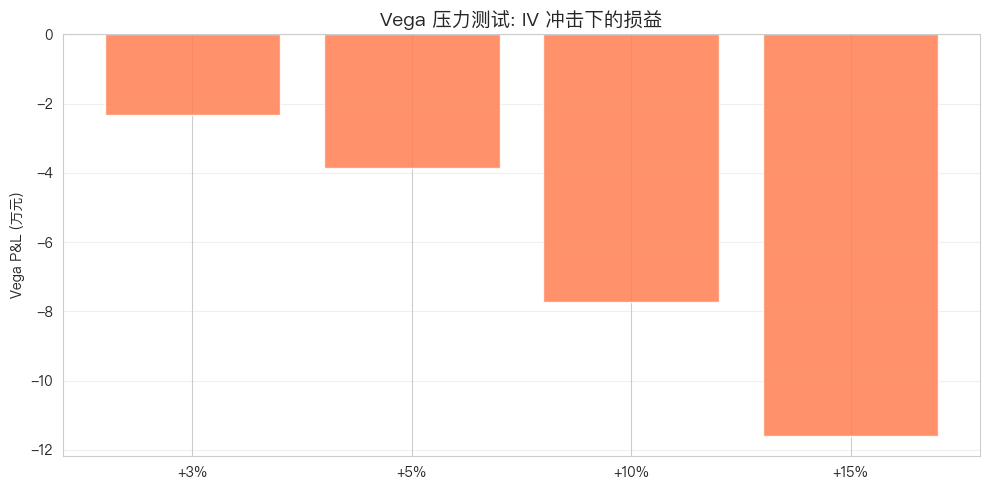

In [7]:
# 1.3 Vega 压力测试
shocks = [0.03, 0.05, 0.10, 0.15]
print('=== Vega 压力测试 ===')
print(f'{"IV 冲击":>10s} {"单日 Vega PnL":>15s} {"占总 PnL 比":>12s}')
print('-' * 40)

total_pnl = sum(t.pnl for t in all_trades)
avg_vega = greeks_daily['portfolio_vega'].mean()
for shock in shocks:
    pnl_shock = avg_vega * shock * 100  # vega per 1%
    pct = pnl_shock / total_pnl * 100 if total_pnl != 0 else 0
    print(f'{shock*100:>+9.0f}% {pnl_shock:>15,.0f} {pct:>11.1f}%')

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
pnls = [avg_vega * s * 100 for s in shocks]
colors = ['green' if p > 0 else 'coral' for p in pnls]
ax.bar([f'+{s*100:.0f}%' for s in shocks], [p/10000 for p in pnls], color=colors, alpha=0.85)
ax.set_ylabel('Vega P&L (万元)')
ax.set_title('Vega 压力测试: IV 冲击下的损益', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='gray', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR + '04_vega_stress.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Delta 风险拆解

Delta 对冲后理论上组合 Delta 应接近 0，但离散对冲、价格跳跃和模型误差会导致残余 Delta 暴露。

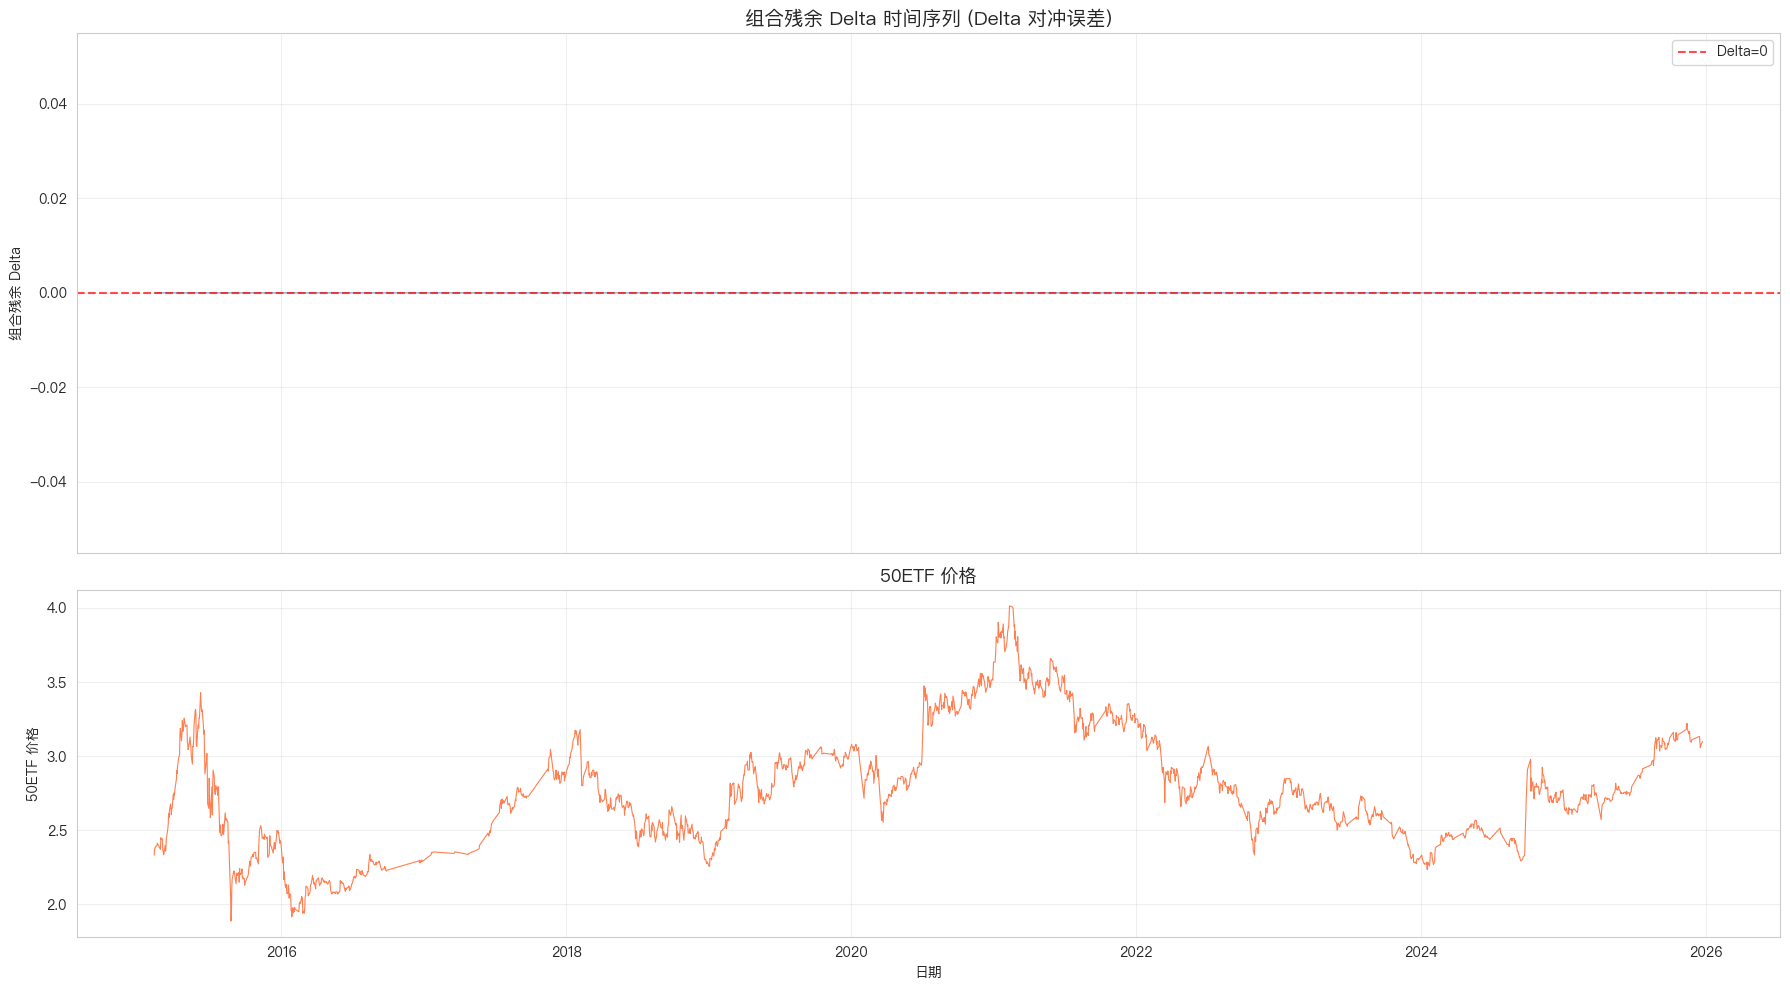

Delta 统计:
  平均残余 Delta: 0
  Delta 标准差: 0
  |Delta| > 1000 天数: 0


In [8]:
# 2.1 残余 Delta 时间序列
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True,
                         gridspec_kw={'height_ratios': [1.5, 1]})

axes[0].plot(greeks_daily.index, greeks_daily['portfolio_delta'], linewidth=0.6, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='Delta=0')
axes[0].set_ylabel('组合残余 Delta')
axes[0].set_title('组合残余 Delta 时间序列 (Delta 对冲误差)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ETF price
axes[1].plot(greeks_daily.index, greeks_daily['etf_price'], linewidth=0.8, color='coral')
axes[1].set_ylabel('50ETF 价格')
axes[1].set_xlabel('日期')
axes[1].set_title('50ETF 价格', fontsize=13)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + '04_delta_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Delta 统计:')
print(f'  平均残余 Delta: {greeks_daily["portfolio_delta"].mean():,.0f}')
print(f'  Delta 标准差: {greeks_daily["portfolio_delta"].std():,.0f}')
print(f'  |Delta| > 1000 天数: {(greeks_daily["portfolio_delta"].abs() > 1000).sum()}')

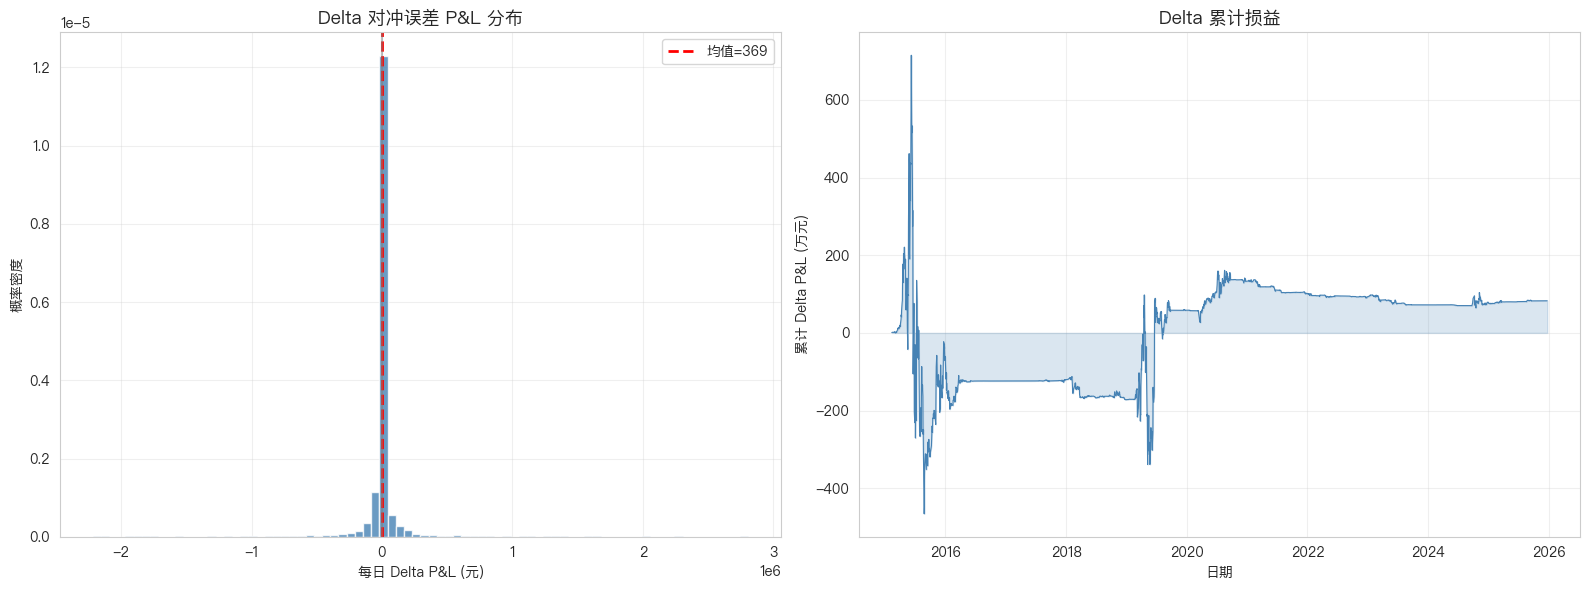

累计 Delta P&L: 826,700 元


In [9]:
# 2.2 Delta 对冲误差 P&L
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Delta P&L distribution
delta_pnl_clean = greeks_daily['delta_pnl'].dropna()
axes[0].hist(delta_pnl_clean, bins=80, color='steelblue', alpha=0.8, edgecolor='white', density=True)
axes[0].axvline(x=delta_pnl_clean.mean(), color='red', linestyle='--', linewidth=2,
                label=f'均值={delta_pnl_clean.mean():.0f}')
axes[0].axvline(x=0, color='gray', linestyle='-', alpha=0.5)
axes[0].set_xlabel('每日 Delta P&L (元)')
axes[0].set_ylabel('概率密度')
axes[0].set_title('Delta 对冲误差 P&L 分布', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative Delta P&L
axes[1].plot(greeks_daily.index, greeks_daily['delta_pnl'].cumsum() / 10000,
             linewidth=0.8, color='steelblue')
axes[1].fill_between(greeks_daily.index, greeks_daily['delta_pnl'].cumsum() / 10000,
                     0, alpha=0.2, color='steelblue')
axes[1].set_ylabel('累计 Delta P&L (万元)')
axes[1].set_xlabel('日期')
axes[1].set_title('Delta 累计损益', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + '04_delta_pnl.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'累计 Delta P&L: {greeks_daily["delta_pnl"].sum():,.0f} 元')

## 3. Gamma 风险拆解

Gamma 衡量 Delta 对标的价格的敏感性。卖出期权的 Gamma 为负，意味着大幅波动（无论方向）都会导致亏损。
Gamma 在临近到期且平值附近时急剧放大。

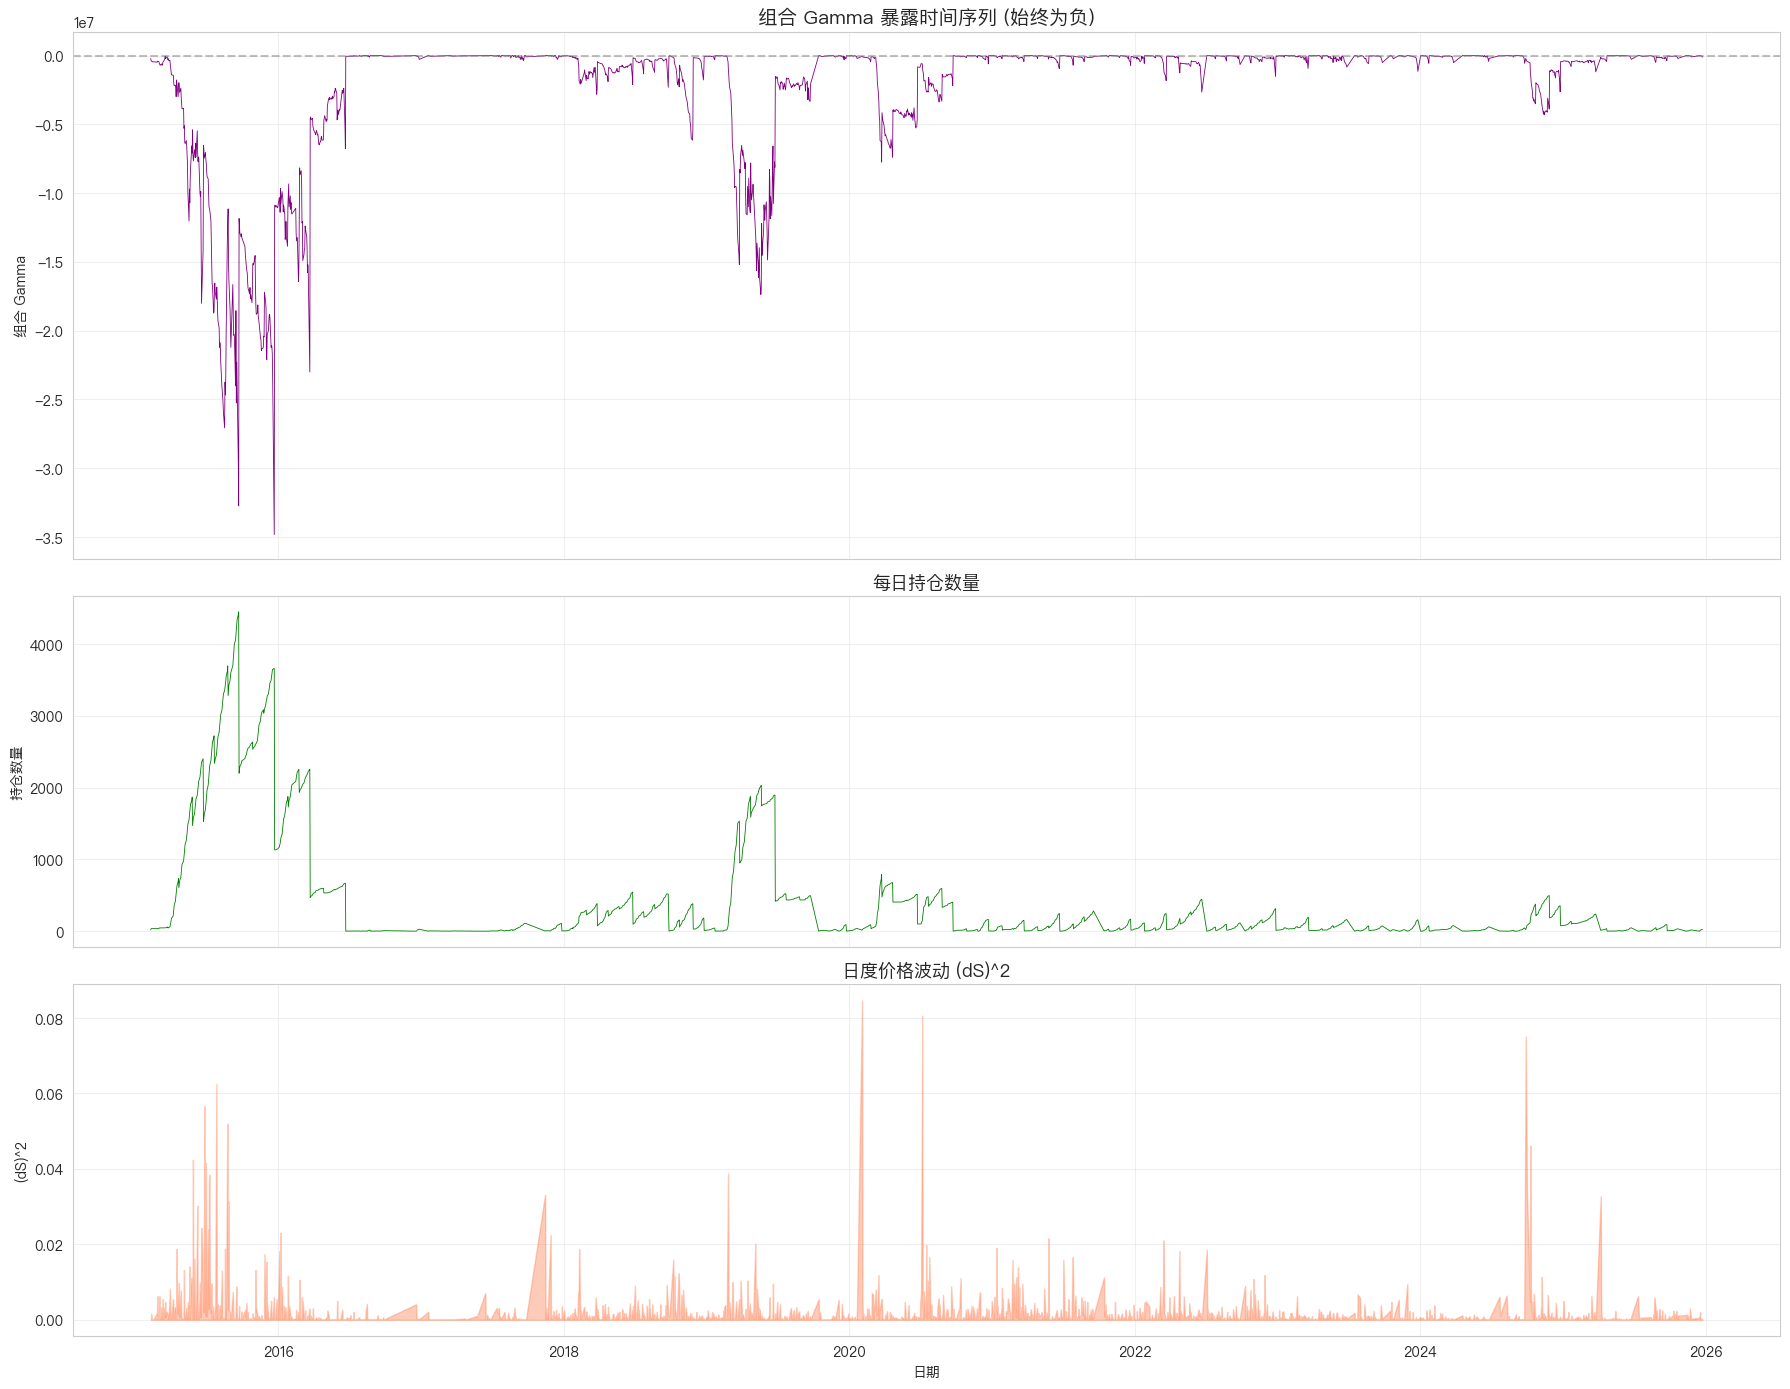

Gamma 统计:
  平均 Gamma: -2,452,736
  Gamma 范围: [-34,818,667, 0]
  Gamma > 0 的天数: 0 / 2243


In [10]:
# 3.1 组合 Gamma 时间序列
fig, axes = plt.subplots(3, 1, figsize=(18, 14), sharex=True,
                         gridspec_kw={'height_ratios': [1.5, 1, 1]})

# Gamma
axes[0].plot(greeks_daily.index, greeks_daily['portfolio_gamma'], linewidth=0.6, color='purple')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_ylabel('组合 Gamma')
axes[0].set_title('组合 Gamma 暴露时间序列 (始终为负)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Number of positions
axes[1].plot(greeks_daily.index, greeks_daily['num_positions'], linewidth=0.6, color='green')
axes[1].set_ylabel('持仓数量')
axes[1].set_title('每日持仓数量', fontsize=13)
axes[1].grid(True, alpha=0.3)

# |dS|^2 (realized variance proxy)
axes[2].fill_between(greeks_daily.index, greeks_daily['dS']**2, 0, alpha=0.4, color='coral')
axes[2].set_ylabel('(dS)^2')
axes[2].set_xlabel('日期')
axes[2].set_title('日度价格波动 (dS)^2', fontsize=13)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + '04_gamma_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Gamma 统计:')
print(f'  平均 Gamma: {greeks_daily["portfolio_gamma"].mean():,.0f}')
print(f'  Gamma 范围: [{greeks_daily["portfolio_gamma"].min():,.0f}, {greeks_daily["portfolio_gamma"].max():,.0f}]')
print(f'  Gamma > 0 的天数: {(greeks_daily["portfolio_gamma"] > 0).sum()} / {len(greeks_daily)}')

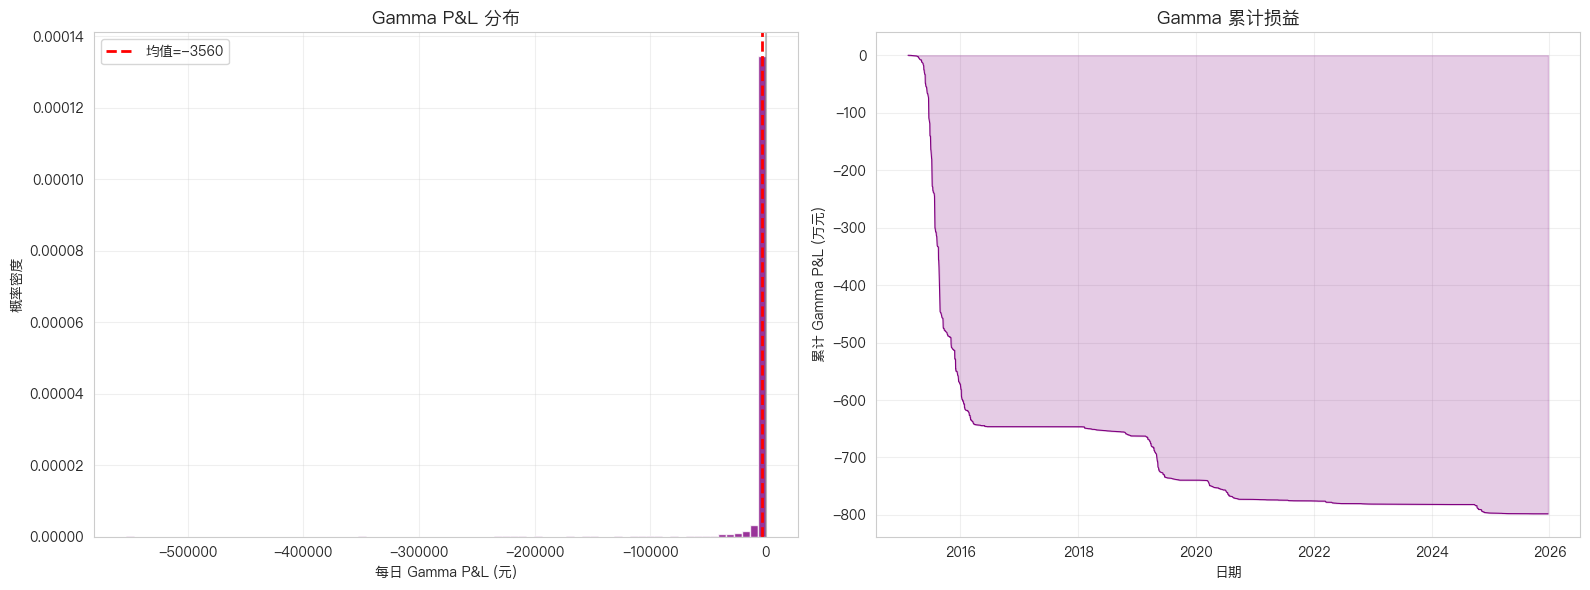

累计 Gamma P&L: -7,980,429 元
Gamma P&L < 0 的天数: 2099 / 2242 (93.6%)


In [11]:
# 3.2 Gamma P&L 分析
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gamma P&L distribution
gamma_pnl_clean = greeks_daily['gamma_pnl'].dropna()
axes[0].hist(gamma_pnl_clean, bins=80, color='purple', alpha=0.8, edgecolor='white', density=True)
axes[0].axvline(x=gamma_pnl_clean.mean(), color='red', linestyle='--', linewidth=2,
                label=f'均值={gamma_pnl_clean.mean():.0f}')
axes[0].axvline(x=0, color='gray', linestyle='-', alpha=0.5)
axes[0].set_xlabel('每日 Gamma P&L (元)')
axes[0].set_ylabel('概率密度')
axes[0].set_title('Gamma P&L 分布', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative Gamma P&L
axes[1].plot(greeks_daily.index, greeks_daily['gamma_pnl'].cumsum() / 10000,
             linewidth=0.8, color='purple')
axes[1].fill_between(greeks_daily.index, greeks_daily['gamma_pnl'].cumsum() / 10000,
                     0, alpha=0.2, color='purple')
axes[1].set_ylabel('累计 Gamma P&L (万元)')
axes[1].set_xlabel('日期')
axes[1].set_title('Gamma 累计损益', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + '04_gamma_pnl.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'累计 Gamma P&L: {greeks_daily["gamma_pnl"].sum():,.0f} 元')
print(f'Gamma P&L < 0 的天数: {(gamma_pnl_clean < 0).sum()} / {len(gamma_pnl_clean)} ({(gamma_pnl_clean < 0).mean()*100:.1f}%)')

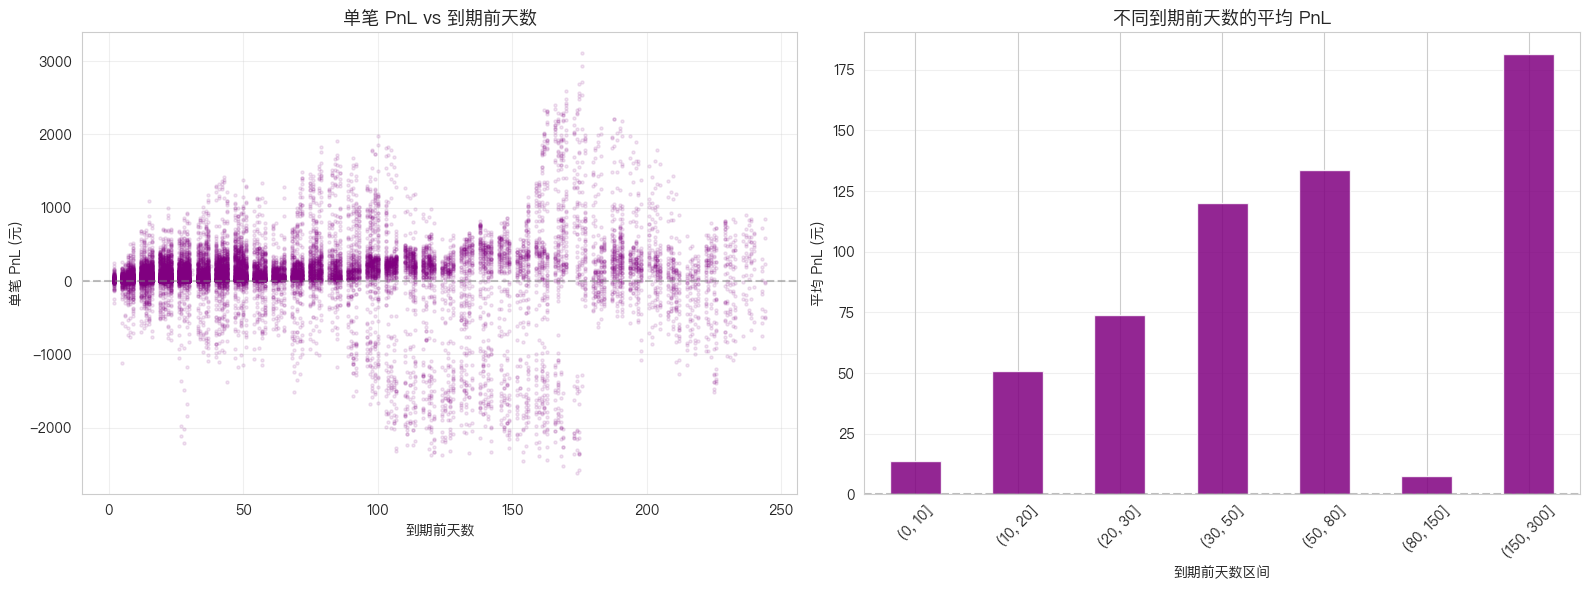

In [12]:
# 3.3 Gamma 临近到期效应
# 对每个交易，记录到期前天数 vs Gamma
trade_gamma_data = []
for t in all_trades:
    if t.exit_date is not None:
        days_to_expiry = (t.expiry - t.entry_date).days
        trade_gamma_data.append({
            'days_to_expiry': days_to_expiry,
            'pnl': t.pnl,
            'entry_iv': t.entry_iv,
            'strike': t.strike,
        })

tg = pd.DataFrame(trade_gamma_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PnL vs days to expiry
axes[0].scatter(tg['days_to_expiry'], tg['pnl'], alpha=0.1, s=5, color='purple')
axes[0].set_xlabel('到期前天数')
axes[0].set_ylabel('单笔 PnL (元)')
axes[0].set_title('单笔 PnL vs 到期前天数', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Average PnL by days bucket
bins = [0, 10, 20, 30, 50, 80, 150, 300]
tg['days_bucket'] = pd.cut(tg['days_to_expiry'], bins=bins)
bucket_stats = tg.groupby('days_bucket', observed=True)['pnl'].agg(['mean', 'std', 'count'])
bucket_stats['mean'].plot(kind='bar', ax=axes[1], color='purple', alpha=0.85)
axes[1].set_xlabel('到期前天数区间')
axes[1].set_ylabel('平均 PnL (元)')
axes[1].set_title('不同到期前天数的平均 PnL', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(SAVE_DIR + '04_gamma_maturity_effect.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 组合 P&L 归因

将总 P&L 分解为：
- **Theta 收益**：时间价值衰减
- **Gamma 损失**：价格波动的非线性损失
- **Vega 损益**：隐含波动率变化
- **Delta 损益**：期权方向性暴露（被 Delta 对冲抵消，对冲 P&L 计入残差）
- **残差**：Delta 对冲 P&L、交易成本、模型误差等

In [13]:
# 4.1 P&L 归因汇总表
attribution = {
    'Theta (时间衰减)': greeks_daily['theta_pnl'].sum(),
    'Gamma (价格波动)': greeks_daily['gamma_pnl'].sum(),
    'Vega (波动率变化)': greeks_daily['vega_pnl'].sum(),
    'Delta (期权方向性)': greeks_daily['delta_pnl'].sum(),
    '残差 (对冲+成本等)': greeks_daily['residual_pnl'].sum(),
}
attr_df = pd.Series(attribution)
total_actual = greeks_daily['daily_pnl'].sum()

print('=== 组合 P&L 归因 ===')
print(f'{"成分":<20s} {"金额 (元)":>15s} {"占比":>10s}')
print('-' * 48)
for name, val in attribution.items():
    pct = val / total_actual * 100 if total_actual != 0 else 0
    print(f'{name:<20s} {val:>15,.0f} {pct:>9.1f}%')
print('-' * 48)
print(f'{"总 P&L":<20s} {total_actual:>15,.0f} {100:>9.1f}%')
print(f'{"归因合计":<20s} {attr_df.sum():>15,.0f} {attr_df.sum()/total_actual*100:>9.1f}%')

=== 组合 P&L 归因 ===
成分                            金额 (元)         占比
------------------------------------------------
Theta (时间衰减)               5,962,109     343.1%
Gamma (价格波动)              -7,980,429    -459.2%
Vega (波动率变化)                 443,901      25.5%
Delta (期权方向性)                826,700      47.6%
残差 (对冲+成本等)                2,485,550     143.0%
------------------------------------------------
总 P&L                      1,737,709     100.0%
归因合计                       1,737,831     100.0%


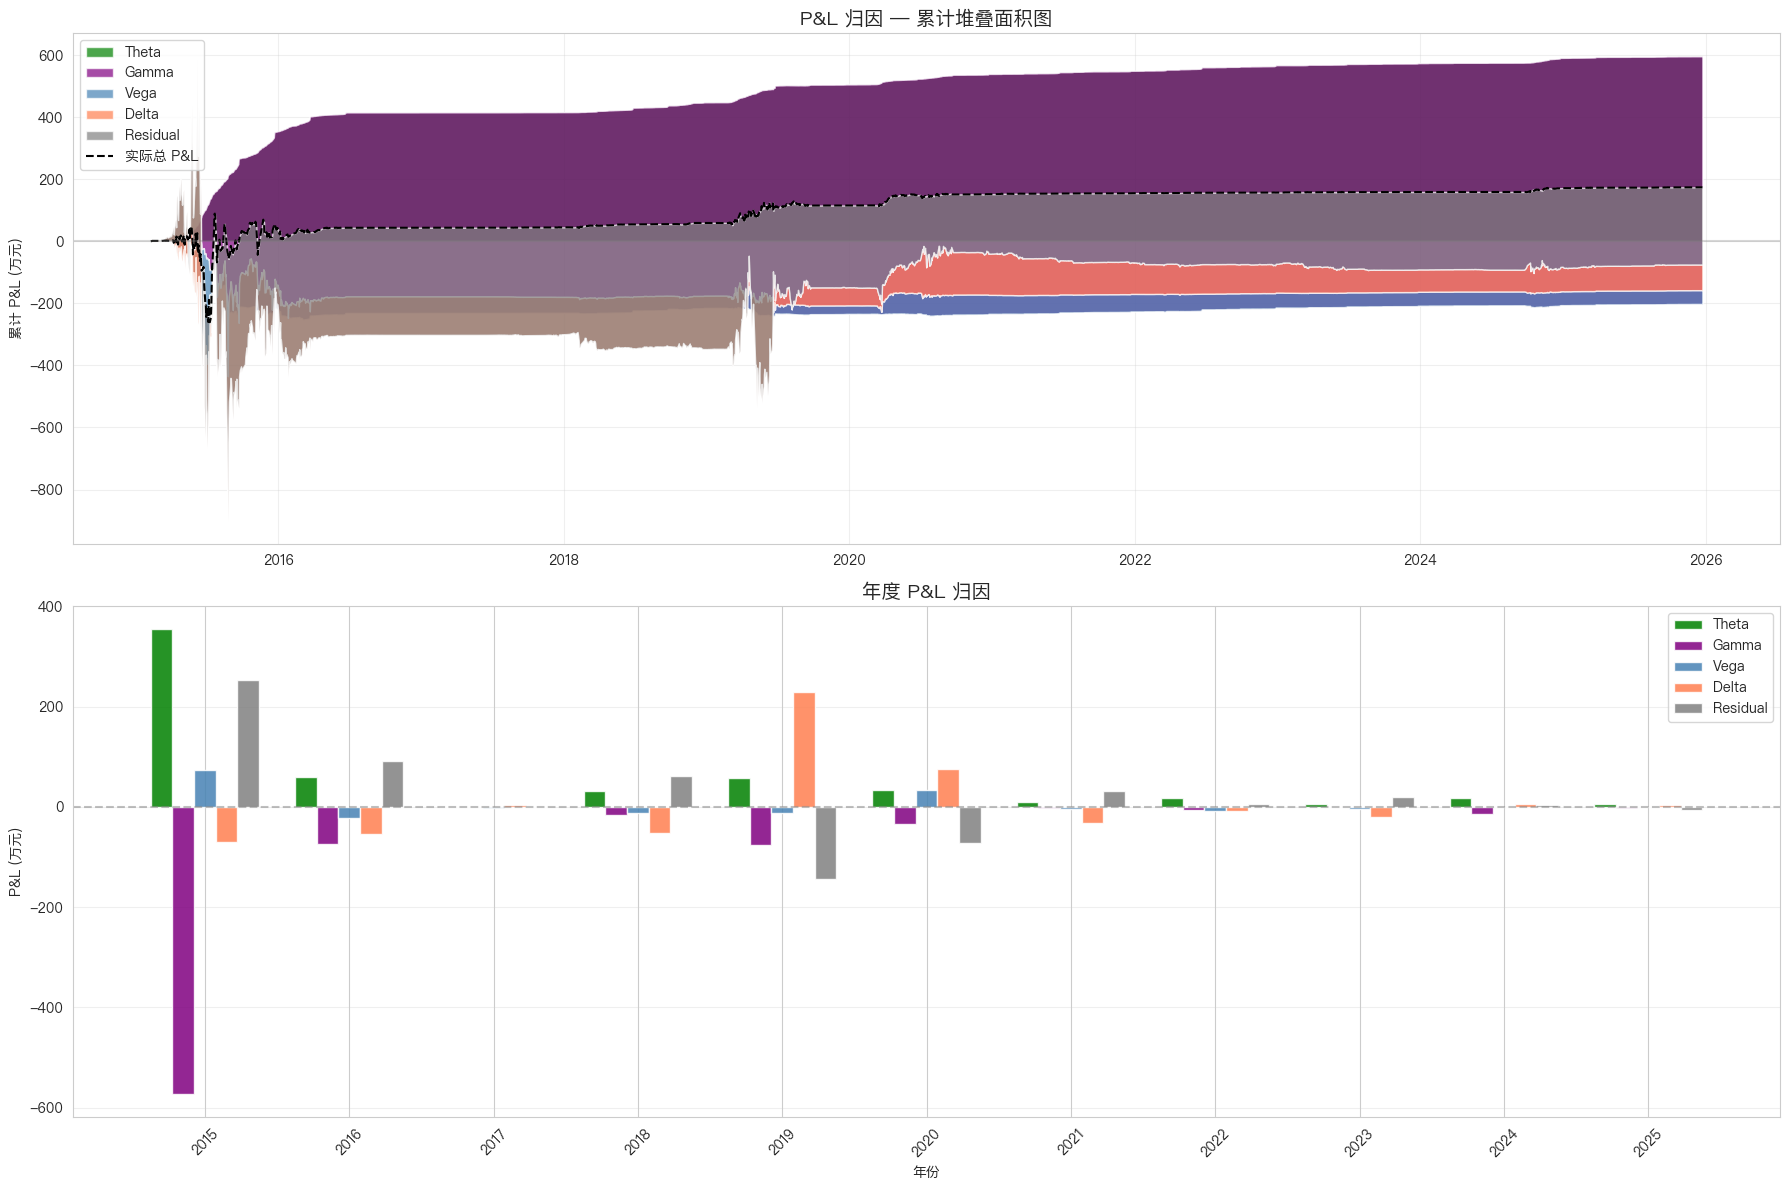

In [14]:
# 4.2 P&L 归因堆叠面积图
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

# Daily stacked attribution
components = ['theta_pnl', 'gamma_pnl', 'vega_pnl', 'delta_pnl', 'residual_pnl']
labels = ['Theta', 'Gamma', 'Vega', 'Delta', 'Residual']
colors = ['green', 'purple', 'steelblue', 'coral', 'gray']

cum_data = pd.DataFrame(index=greeks_daily.index)
for comp, label in zip(components, labels):
    cum_data[label] = greeks_daily[comp].fillna(0).cumsum() / 10000

# Stacked area
axes[0].stackplot(cum_data.index,
                  [cum_data[label].values for label in labels],
                  labels=labels, colors=colors, alpha=0.7)
axes[0].plot(greeks_daily.index, equity.reindex(greeks_daily.index, fill_value=0) / 10000,
             linewidth=1.5, color='black', linestyle='--', label='实际总 P&L')
axes[0].set_ylabel('累计 P&L (万元)')
axes[0].set_title('P&L 归因 — 累计堆叠面积图', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper left', fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0, color='gray', linestyle='-', alpha=0.3)

# Annual attribution bar chart
annual_attr = greeks_daily[components].copy()
annual_attr.columns = labels
annual_attr['year'] = greeks_daily.index.year
annual_sum = annual_attr.groupby('year').sum() / 10000

x = np.arange(len(annual_sum.index))
width = 0.15
for i, (label, color) in enumerate(zip(labels, colors)):
    axes[1].bar(x + (i - 2) * width, annual_sum[label], width,
                color=color, alpha=0.85, label=label)

axes[1].set_xticks(x)
axes[1].set_xticklabels(annual_sum.index, rotation=45)
axes[1].set_xlabel('年份')
axes[1].set_ylabel('P&L (万元)')
axes[1].set_title('年度 P&L 归因', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(SAVE_DIR + '04_pnl_attribution.png', dpi=150, bbox_inches='tight')
plt.show()

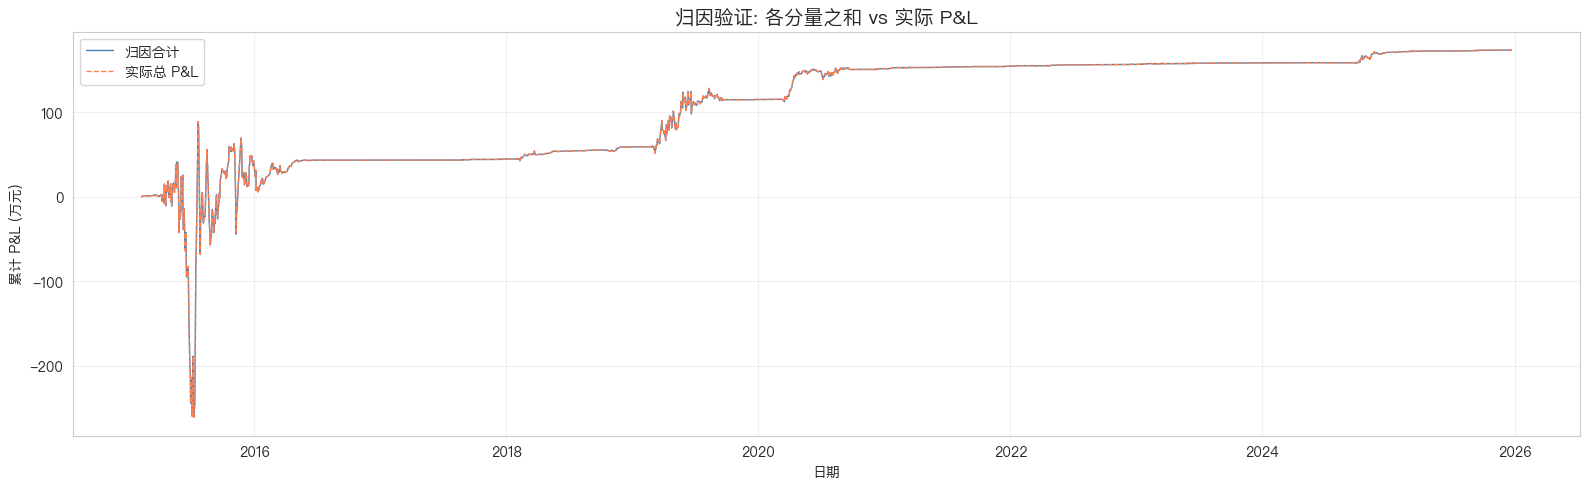

归因误差: 122 元 (0.01%)


In [15]:
# 4.3 归因验证：各分量之和 vs 实际 P&L
fig, ax = plt.subplots(figsize=(16, 5))

attr_sum = greeks_daily[['theta_pnl', 'gamma_pnl', 'vega_pnl', 'delta_pnl', 'residual_pnl']].sum(axis=1)
actual_pnl = greeks_daily['daily_pnl']

ax.plot(greeks_daily.index, attr_sum.cumsum() / 10000, linewidth=1, color='steelblue', label='归因合计')
ax.plot(greeks_daily.index, actual_pnl.cumsum() / 10000, linewidth=1, color='coral',
        linestyle='--', label='实际总 P&L')
ax.set_ylabel('累计 P&L (万元)')
ax.set_xlabel('日期')
ax.set_title('归因验证: 各分量之和 vs 实际 P&L', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + '04_attribution_validation.png', dpi=150, bbox_inches='tight')
plt.show()

error = abs(attr_sum.sum() - actual_pnl.sum())
print(f'归因误差: {error:,.0f} 元 ({error/abs(actual_pnl.sum())*100:.2f}%)')

## 5. 收益分布与回撤结构

分析策略的收益分布特征：偏度、峰度、VaR、ES，以及回撤的持续时间和严重程度。

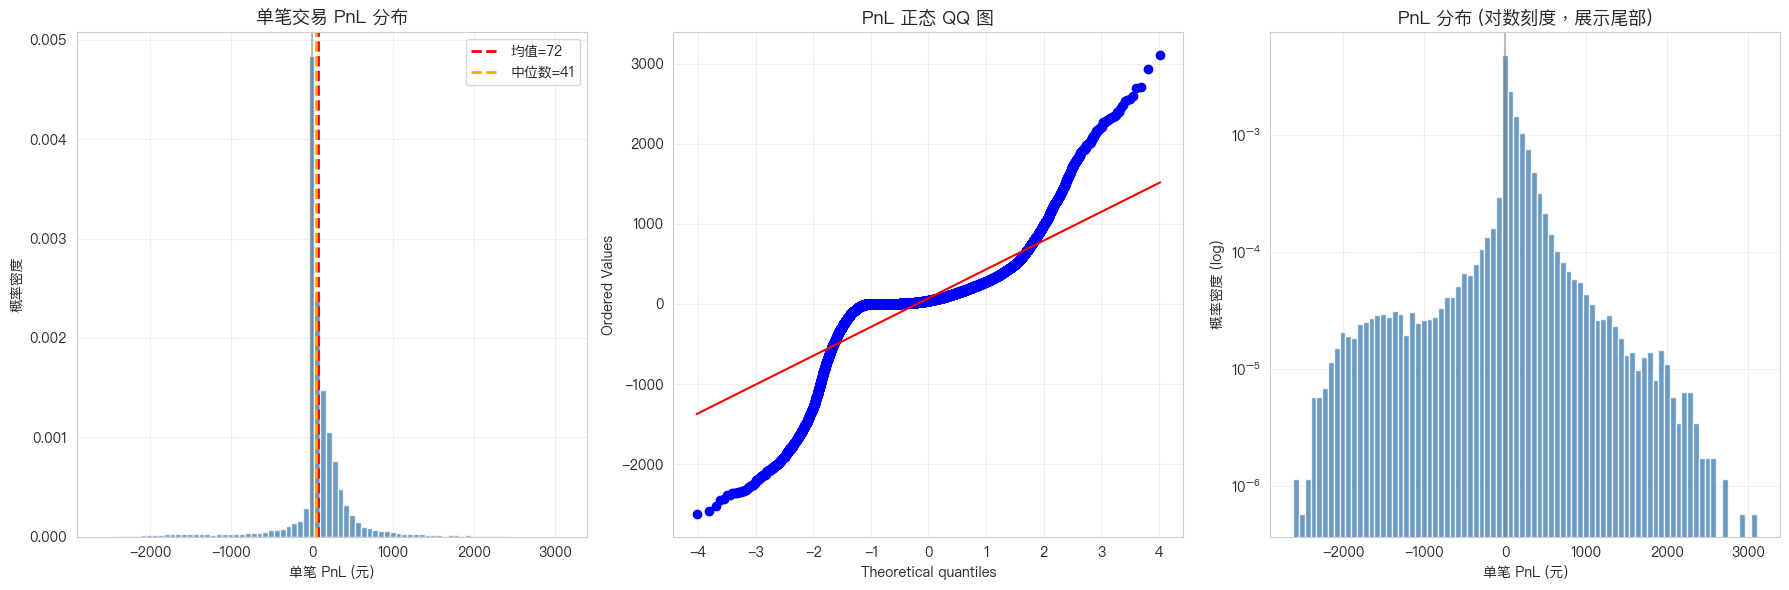

=== 单笔 PnL 分布统计 ===
  均值: 72
  中位数: 41
  标准差: 428
  偏度: -0.945
  峰度: 10.508
  VaR (5%): -496
  VaR (1%): -1734
  ES (5%): -1235
  ES (1%): -1994


In [16]:
# 5.1 单笔交易 PnL 分布
pnls = np.array([t.pnl for t in all_trades])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Histogram
axes[0].hist(pnls, bins=80, color='steelblue', alpha=0.8, edgecolor='white', density=True)
axes[0].axvline(x=np.mean(pnls), color='red', linestyle='--', linewidth=2, label=f'均值={np.mean(pnls):.0f}')
axes[0].axvline(x=np.median(pnls), color='orange', linestyle='--', linewidth=2, label=f'中位数={np.median(pnls):.0f}')
axes[0].axvline(x=0, color='gray', linestyle='-', alpha=0.5)
axes[0].set_xlabel('单笔 PnL (元)')
axes[0].set_ylabel('概率密度')
axes[0].set_title('单笔交易 PnL 分布', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# QQ plot
stats.probplot(pnls, dist='norm', plot=axes[1])
axes[1].set_title('PnL 正态 QQ 图', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Log-scale tail
axes[2].hist(pnls, bins=80, color='steelblue', alpha=0.8, edgecolor='white', density=True)
axes[2].set_yscale('log')
axes[2].axvline(x=0, color='gray', linestyle='-', alpha=0.5)
axes[2].set_xlabel('单笔 PnL (元)')
axes[2].set_ylabel('概率密度 (log)')
axes[2].set_title('PnL 分布 (对数刻度，展示尾部)', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR + '04_pnl_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Distribution statistics
print('=== 单笔 PnL 分布统计 ===')
print(f'  均值: {np.mean(pnls):.0f}')
print(f'  中位数: {np.median(pnls):.0f}')
print(f'  标准差: {np.std(pnls):.0f}')
print(f'  偏度: {pd.Series(pnls).skew():.3f}')
print(f'  峰度: {pd.Series(pnls).kurtosis():.3f}')
print(f'  VaR (5%): {np.percentile(pnls, 5):.0f}')
print(f'  VaR (1%): {np.percentile(pnls, 1):.0f}')
print(f'  ES (5%): {pnls[pnls <= np.percentile(pnls, 5)].mean():.0f}')
print(f'  ES (1%): {pnls[pnls <= np.percentile(pnls, 1)].mean():.0f}')

=== 尾部风险分析 ===
最差 5% 交易: n=1203, 均值=-1235, 范围=[-2621, -496]
最好 5% 交易: n=1203, 均值=1088, 范围=[603, 3107]
尾部比率 (worst/best): 1.14


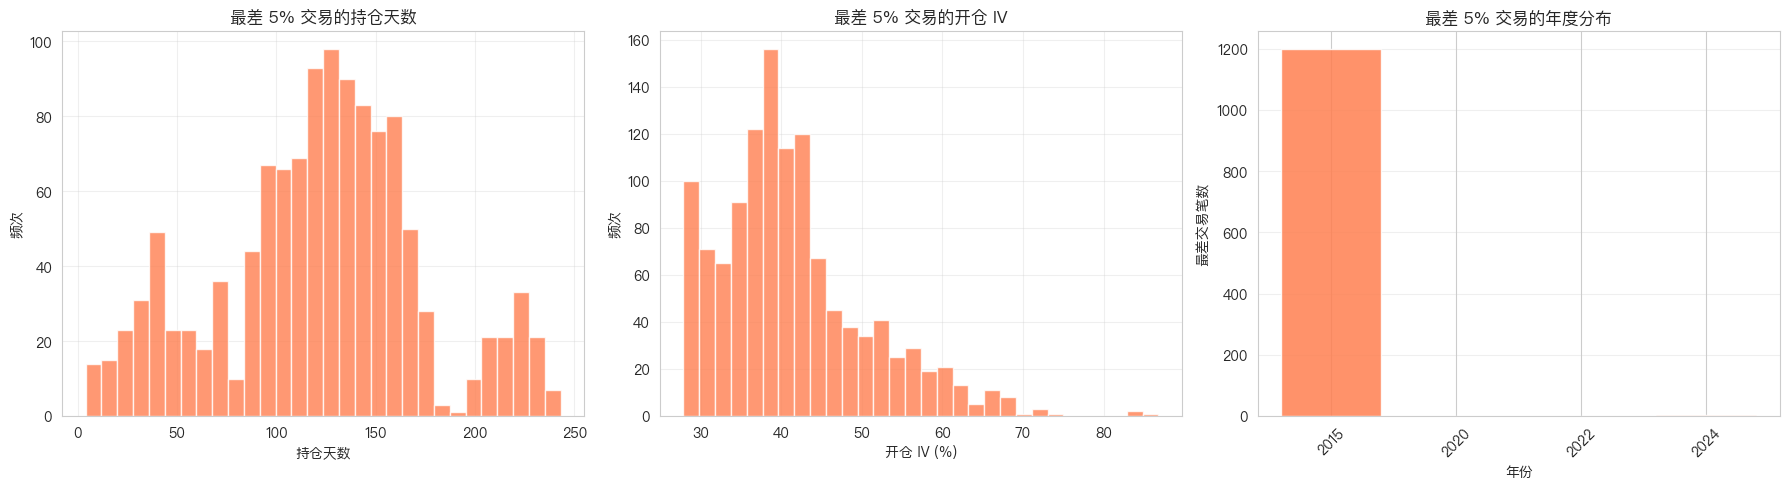

In [17]:
# 5.2 尾部风险分析 — 最差 5% 交易
worst_5pct = pnls[pnls <= np.percentile(pnls, 5)]
best_5pct = pnls[pnls >= np.percentile(pnls, 95)]

print('=== 尾部风险分析 ===')
print(f'最差 5% 交易: n={len(worst_5pct)}, 均值={worst_5pct.mean():.0f}, 范围=[{worst_5pct.min():.0f}, {worst_5pct.max():.0f}]')
print(f'最好 5% 交易: n={len(best_5pct)}, 均值={best_5pct.mean():.0f}, 范围=[{best_5pct.min():.0f}, {best_5pct.max():.0f}]')
print(f'尾部比率 (worst/best): {abs(worst_5pct.mean() / best_5pct.mean()):.2f}')

# Worst trades characteristics
worst_trades = [t for t in all_trades if t.pnl <= np.percentile(pnls, 5)]
worst_df = pd.DataFrame([{
    'entry_date': t.entry_date, 'exit_date': t.exit_date,
    'pnl': t.pnl, 'holding_days': t.holding_days,
    'entry_iv': t.entry_iv, 'strike': t.strike,
} for t in worst_trades])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(worst_df['holding_days'], bins=30, color='coral', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('持仓天数')
axes[0].set_ylabel('频次')
axes[0].set_title('最差 5% 交易的持仓天数', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].hist(worst_df['entry_iv'] * 100, bins=30, color='coral', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('开仓 IV (%)')
axes[1].set_ylabel('频次')
axes[1].set_title('最差 5% 交易的开仓 IV', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

worst_df['year'] = worst_df['entry_date'].dt.year
yearly_worst = worst_df.groupby('year').size()
axes[2].bar(yearly_worst.index.astype(str), yearly_worst.values, color='coral', alpha=0.85)
axes[2].set_xlabel('年份')
axes[2].set_ylabel('最差交易笔数')
axes[2].set_title('最差 5% 交易的年度分布', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(SAVE_DIR + '04_tail_risk.png', dpi=150, bbox_inches='tight')
plt.show()

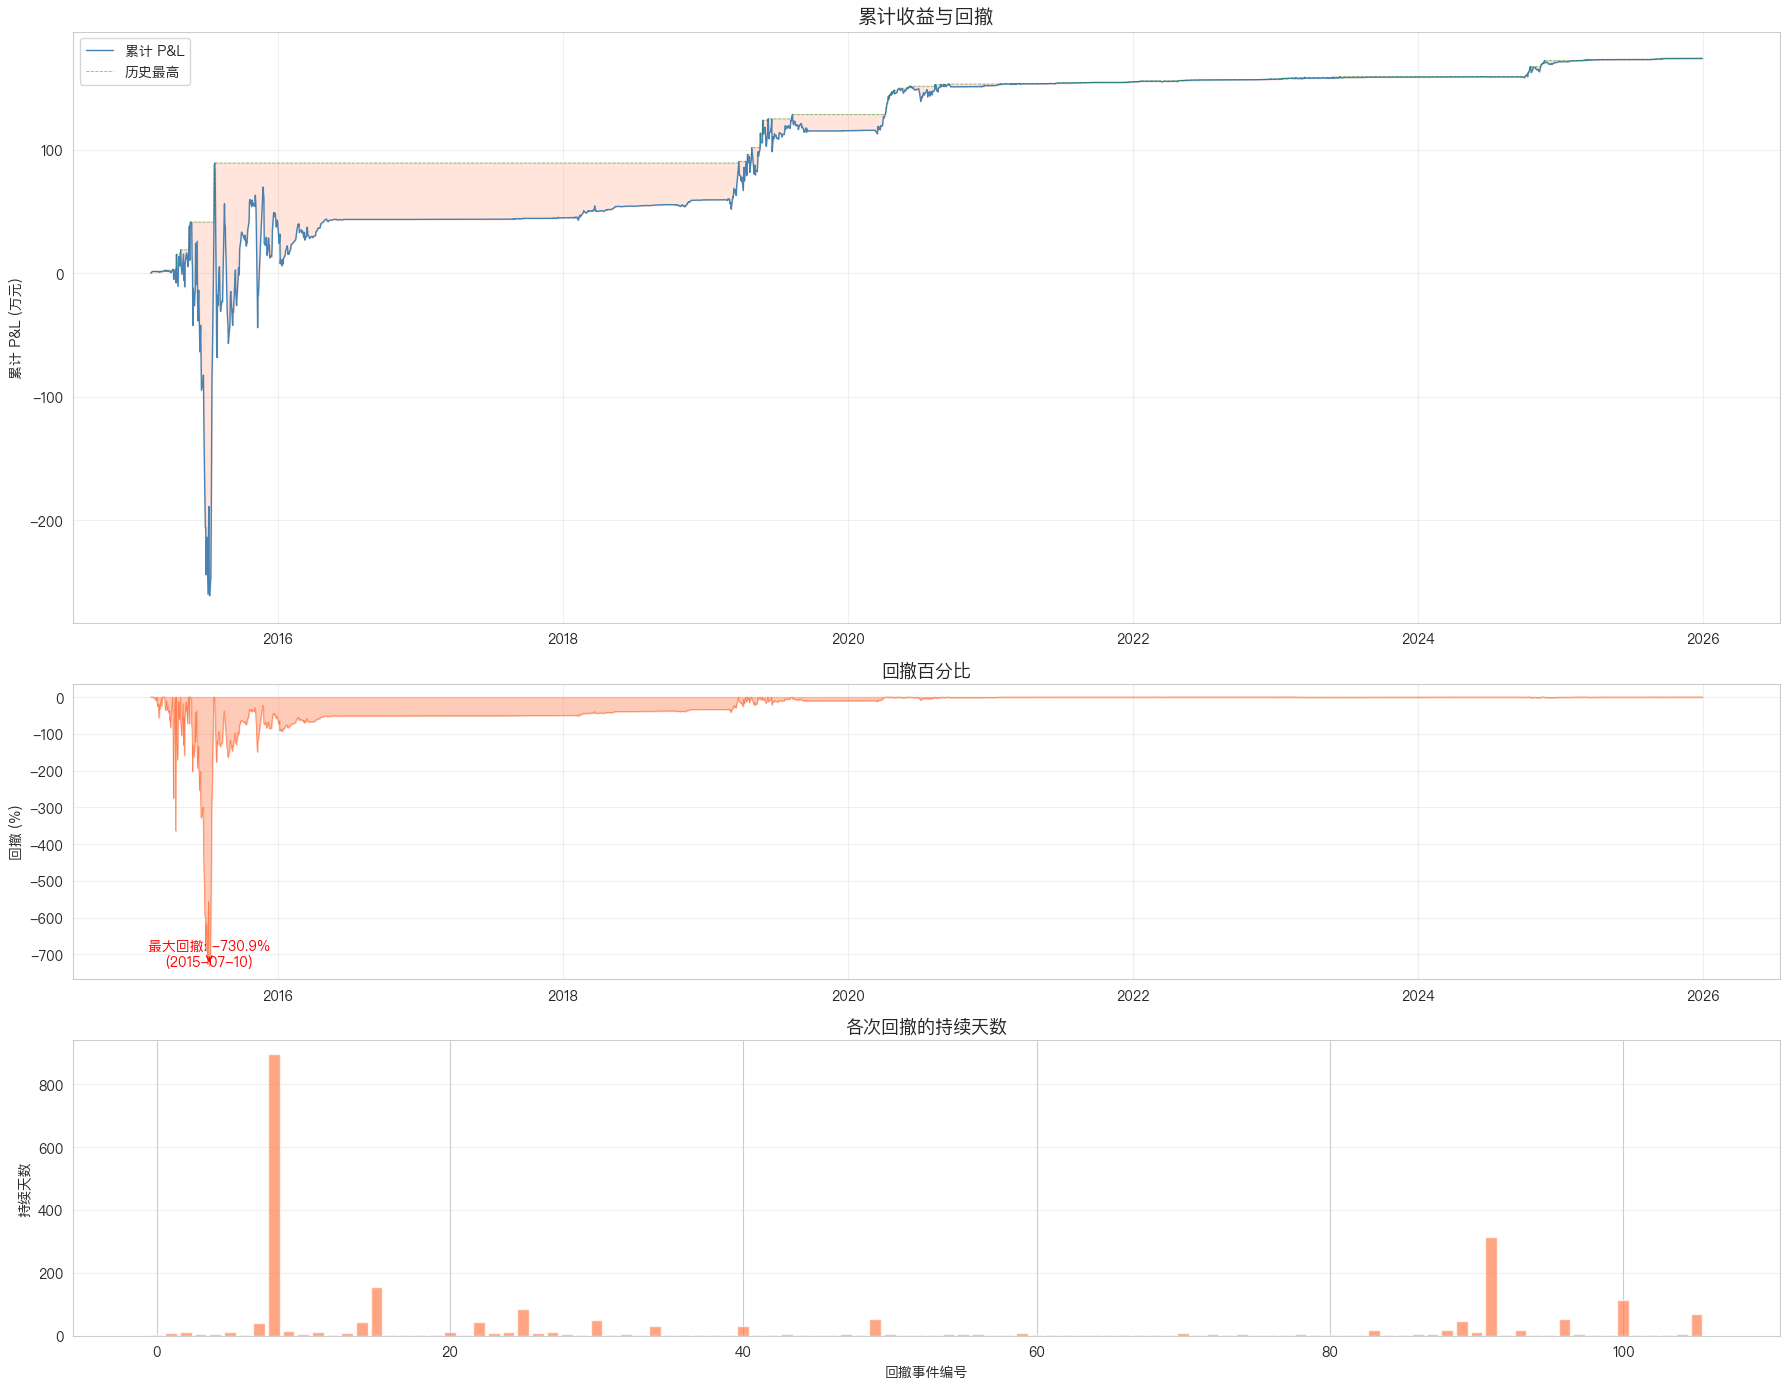

equity 日期范围: 2015-02-09 ~ 2025-12-31
=== 回撤统计 ===
  最大回撤: -3,023,528 元 (-730.9%)
  最大回撤日期: 2015-07-10
  平均回撤: -212,162 元
  回撤 > 5% 天数: 1208 / 2649 (45.6%)
  回撤事件次数: 106
  平均回撤持续: 23 天
  最长回撤持续: 895 天


In [18]:
# 5.3 回撤分析
if not equity.empty:
    cummax = equity.cummax()
    drawdown = equity - cummax
    dd_pct = drawdown / cummax * 100

    fig, axes = plt.subplots(3, 1, figsize=(18, 14),
                             gridspec_kw={'height_ratios': [2, 1, 1]})

    # Equity curve with high water mark
    axes[0].plot(equity.index, equity.values / 10000, linewidth=1, color='steelblue', label='累计 P&L')
    axes[0].plot(equity.index, cummax.values / 10000, linewidth=0.6, color='green',
                linestyle='--', alpha=0.5, label='历史最高')
    axes[0].fill_between(equity.index, equity.values / 10000, cummax.values / 10000,
                        alpha=0.2, color='coral')
    axes[0].set_ylabel('累计 P&L (万元)')
    axes[0].set_title('累计收益与回撤', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Drawdown percentage
    axes[1].fill_between(dd_pct.index, dd_pct.values, 0, alpha=0.4, color='coral')
    axes[1].plot(dd_pct.index, dd_pct.values, linewidth=0.5, color='coral')
    axes[1].set_ylabel('回撤 (%)')
    axes[1].set_title('回撤百分比', fontsize=13)
    axes[1].grid(True, alpha=0.3)

    max_dd_idx = dd_pct.idxmin()
    axes[1].annotate(f'最大回撤: {dd_pct.min():.1f}%\n({max_dd_idx.date()})',
                    xy=(max_dd_idx, dd_pct.min()), xytext=(max_dd_idx, dd_pct.min() - 2),
                    arrowprops=dict(arrowstyle='->', color='red'),
                    fontsize=10, color='red', ha='center')

    # Underwater duration (consecutive days in drawdown)
    in_dd = (drawdown < 0).astype(int)
    dd_groups = (in_dd != in_dd.shift()).cumsum()
    dd_durations = in_dd.groupby(dd_groups).sum()
    dd_durations = dd_durations[dd_durations > 0]

    if len(dd_durations) > 0:
        axes[2].bar(range(len(dd_durations)), dd_durations.values, color='coral', alpha=0.7)
        axes[2].set_xlabel('回撤事件编号')
        axes[2].set_ylabel('持续天数')
        axes[2].set_title('各次回撤的持续天数', fontsize=13)
        axes[2].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(SAVE_DIR + '04_drawdown_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'equity 日期范围: {equity.index.min().date()} ~ {equity.index.max().date()}')
    print('=== 回撤统计 ===')
    print(f'  最大回撤: {drawdown.min():,.0f} 元 ({dd_pct.min():.1f}%)')
    print(f'  最大回撤日期: {max_dd_idx.date()}')
    print(f'  平均回撤: {drawdown[drawdown < 0].mean():,.0f} 元')
    print(f'  回撤 > 5% 天数: {(dd_pct < -5).sum()} / {len(dd_pct)} ({(dd_pct < -5).mean()*100:.1f}%)')
    print(f'  回撤事件次数: {len(dd_durations)}')
    print(f'  平均回撤持续: {dd_durations.mean():.0f} 天')
    print(f'  最长回撤持续: {dd_durations.max():.0f} 天')

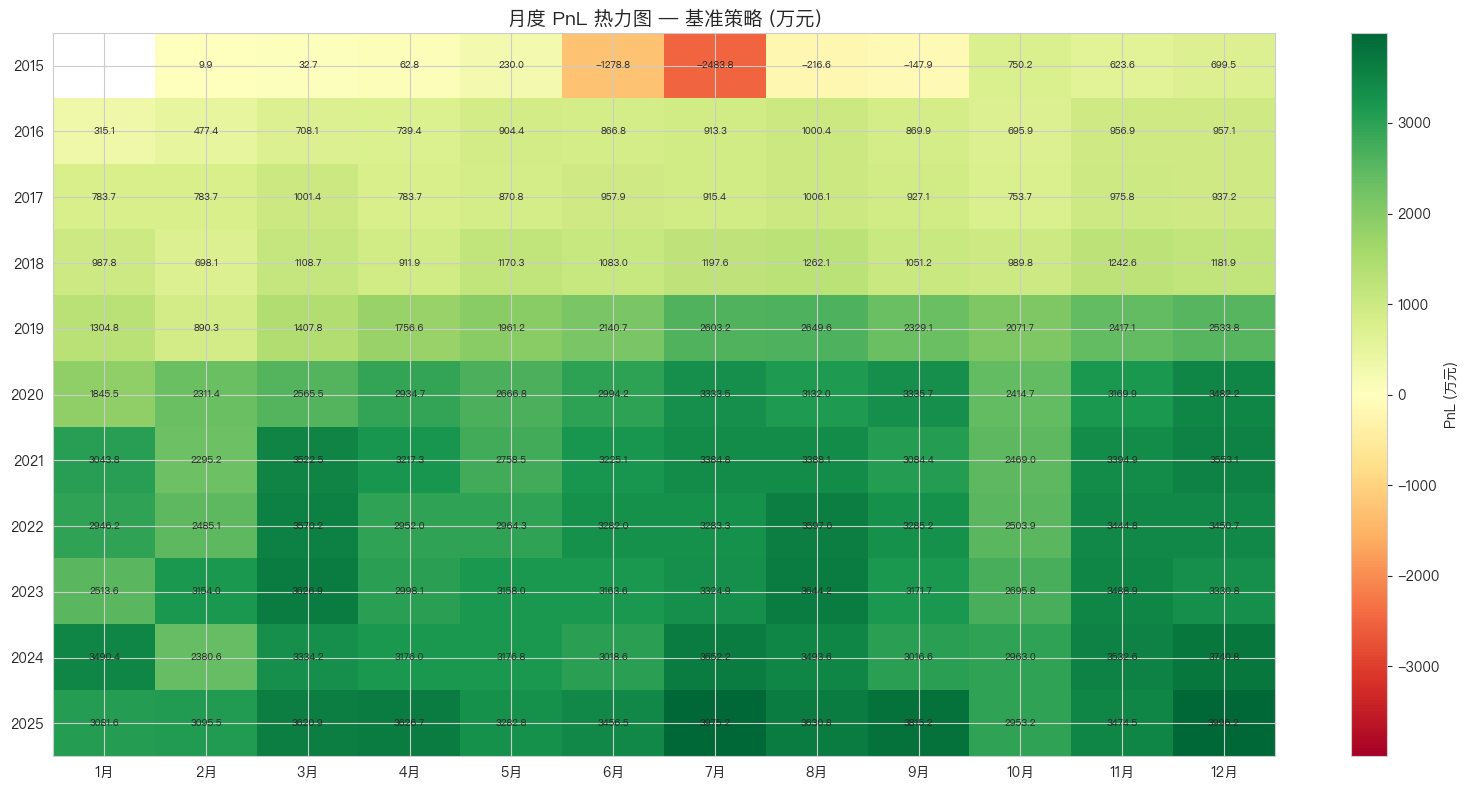

月度统计:
  盈利月: 127 / 131
  亏损月: 4 / 131
  最大月盈利: 39,961,951 元
  最大月亏损: -24,838,410 元


In [19]:
# 5.4 月度 P&L 热力图
if not equity.empty:
    monthly = equity.resample('ME').sum()
    monthly_df = pd.DataFrame({
        'Year': monthly.index.year,
        'Month': monthly.index.month,
        'PnL': monthly.values
    })
    pivot = monthly_df.pivot_table(index='Year', columns='Month', values='PnL', aggfunc='sum')

    fig, ax = plt.subplots(figsize=(16, 8))
    vmax = abs(pivot.values[~np.isnan(pivot.values)]).max()
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(12))
    ax.set_xticklabels([f'{m}月' for m in range(1, 13)])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title('月度 PnL 热力图 — 基准策略 (万元)', fontsize=14, fontweight='bold')

    for i in range(len(pivot.index)):
        for j in range(12):
            val = pivot.values[i, j]
            if not np.isnan(val) and abs(val) > 0:
                ax.text(j, i, f'{val/10000:.1f}', ha='center', va='center', fontsize=7)

    plt.colorbar(im, ax=ax, label='PnL (万元)', format=plt.FuncFormatter(lambda x, _: f'{x/10000:.0f}'))
    plt.tight_layout()
    plt.savefig(SAVE_DIR + '04_monthly_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'月度统计:')
    print(f'  盈利月: {(monthly > 0).sum()} / {len(monthly)}')
    print(f'  亏损月: {(monthly < 0).sum()} / {len(monthly)}')
    print(f'  最大月盈利: {monthly.max():,.0f} 元')
    print(f'  最大月亏损: {monthly.min():,.0f} 元')

In [20]:
# 5.5 年度风险指标汇总
annual_risk = []
for year in sorted(greeks_daily.index.year.unique()):
    mask = greeks_daily.index.year == year
    sub = greeks_daily[mask]
    if len(sub) == 0:
        continue
    year_pnls = np.array([t.pnl for t in all_trades if t.entry_date.year == year])
    if len(year_pnls) == 0:
        continue
    annual_risk.append({
        'year': year,
        'total_pnl': year_pnls.sum(),
        'avg_pnl': year_pnls.mean(),
        'std_pnl': year_pnls.std(),
        'skew': pd.Series(year_pnls).skew(),
        'kurtosis': pd.Series(year_pnls).kurtosis(),
        'var_5': np.percentile(year_pnls, 5),
        'es_5': year_pnls[year_pnls <= np.percentile(year_pnls, 5)].mean() if len(year_pnls[year_pnls <= np.percentile(year_pnls, 5)]) > 0 else 0,
        'win_rate': (year_pnls > 0).mean() * 100,
        'avg_vega': sub['portfolio_vega'].mean(),
        'avg_gamma': sub['portfolio_gamma'].mean(),
    })

ar = pd.DataFrame(annual_risk).set_index('year')
print('=== 年度风险指标汇总 ===')
print(ar.to_string(float_format=lambda x: f'{x:.1f}'))

=== 年度风险指标汇总 ===
      total_pnl  avg_pnl  std_pnl  skew  kurtosis   var_5    es_5  win_rate  avg_vega   avg_gamma
year                                                                                             
2015   252000.3     29.2    678.4  -0.5       2.7 -1456.5 -1816.5      69.9  -51031.2 -12102757.5
2016   183366.9     93.1    132.1   1.5       2.8    -2.8   -76.5      92.3   -8569.8  -4860877.4
2017    13634.4     50.3     53.7   2.0       4.0     0.0    -2.9      97.4     -65.6    -51072.0
2018   142828.8     61.8    118.9   3.2      15.1    -0.0   -71.2      93.6   -1753.1   -955452.3
2019   561414.6    161.6    166.2   2.2       7.7    -0.4   -44.1      94.1  -12451.9  -4431800.5
2020   364351.9    168.9    253.1   1.6       2.7   -65.7  -173.3      90.1   -4063.0  -1913161.3
2021    32624.3     26.3     54.4   2.9      19.0    -1.0   -25.6      90.1    -163.8    -94677.3
2022    19249.7     12.0     59.1   0.4      30.4    -8.4   -91.5      86.8    -283.7   -249619.9
202